# 05 — Scale orders: can tranching the entry smooth the tail?

Same 766 pooled pumps. Instead of shorting full size at the trigger, scale in
over time with different weight profiles. Exit all at +240m.

Goal: trade a bit of mean profit for a thinner left tail (the runner risk).

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *

paths = np.load('_out/pump_paths.npy')   # (n_events, 541), normalized to trigger=0
PRE = 60
rel = 1.0 + paths                        # price relative to trigger
EXIT = 240                               # close the whole short at +240m
print('events:', paths.shape[0])

events: 766


In [2]:
def short_pnl(profile):
    """profile = list of (delay_minutes, weight). Returns per-event short PnL array."""
    pe = rel[:, PRE + EXIT]
    pnl = np.zeros(rel.shape[0])
    wsum = sum(w for _, w in profile)
    for d, w in profile:
        p_in = rel[:, PRE + d]
        pnl += (w / wsum) * (1.0 - pe / p_in)   # short: profit if exit < entry
    return pnl

PROFILES = {
    'full @ trigger':      [(0, 1.0)],
    'uniform 0/15/30/45':  [(0, 1), (15, 1), (30, 1), (45, 1)],
    'front 50/30/20':      [(0, .5), (15, .3), (30, .2)],
    'back 20/30/50':       [(0, .2), (15, .3), (30, .5)],
    'back-heavy 10/20/30/40': [(0, .1), (15, .2), (30, .3), (45, .4)],
}

def stats(p):
    return dict(mean=p.mean()*100, median=np.median(p)*100, win=(p>0).mean()*100,
                std=p.std()*100, q10=np.quantile(p, .1)*100,
                sharpe=p.mean()/p.std())   # per-trade mean/std

res = {name: stats(short_pnl(prof)) for name, prof in PROFILES.items()}
print(f"{'profile':<24}{'mean':>8}{'median':>8}{'win%':>7}{'std':>8}{'q10':>8}{'m/std':>8}")
for name, s in res.items():
    print(f"{name:<24}{s['mean']:>+7.2f}%{s['median']:>+7.2f}%{s['win']:>6.1f}%"
          f"{s['std']:>7.2f}%{s['q10']:>+7.2f}%{s['sharpe']:>8.3f}")

profile                     mean  median   win%     std     q10   m/std
full @ trigger            +1.47%  +1.87%  64.5%   5.92%  -6.42%   0.248
uniform 0/15/30/45        +0.60%  +0.98%  59.0%   4.64%  -5.21%   0.128
front 50/30/20            +0.90%  +1.34%  61.6%   5.12%  -5.55%   0.176
back 20/30/50             +0.58%  +0.97%  59.0%   4.68%  -5.17%   0.124
back-heavy 10/20/30/40    +0.41%  +0.63%  57.0%   4.44%  -4.95%   0.093


## Distribution: does the left tail actually shrink?

[saved] notebooks\_out\05_scale_dist.png


WindowsPath('C:/projects/researchlab/notebooks/_out/05_scale_dist.png')

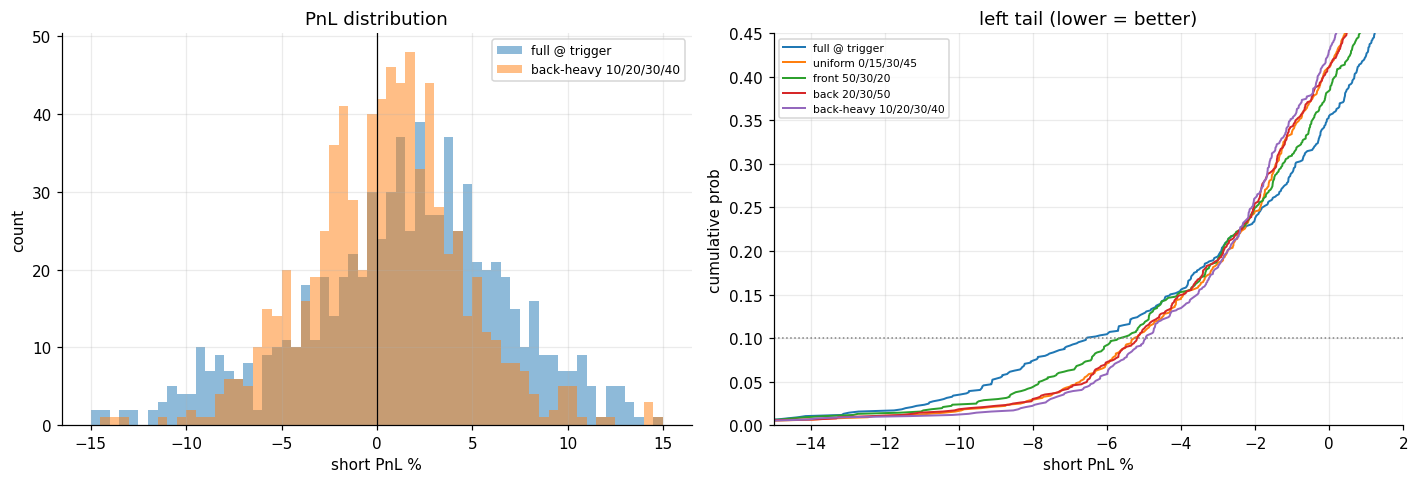

In [3]:
fig, (axh, axc) = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.linspace(-15, 15, 61)
for name in ['full @ trigger', 'back-heavy 10/20/30/40']:
    p = short_pnl(PROFILES[name]) * 100
    axh.hist(p, bins=bins, alpha=0.5, label=name)
axh.axvline(0, color='k', lw=0.8); axh.set_xlabel('short PnL %'); axh.set_ylabel('count')
axh.set_title('PnL distribution'); axh.legend(fontsize=8)

# CDF zoom on the left tail
for name in PROFILES:
    p = np.sort(short_pnl(PROFILES[name]) * 100)
    cdf = np.arange(1, len(p)+1) / len(p)
    axc.plot(p, cdf, label=name, lw=1.3)
axc.set_xlim(-15, 2); axc.set_ylim(0, 0.45)
axc.axhline(0.1, color='gray', ls=':', lw=1)
axc.set_xlabel('short PnL %'); axc.set_ylabel('cumulative prob')
axc.set_title('left tail (lower = better)'); axc.legend(fontsize=7)
show('05_scale_dist')

## Sweep: how much weight to push to the back?

Interpolate from fully-front (all at trigger) to fully-back (all at +45m) and
watch mean vs the q10 tail trade off.

[saved] notebooks\_out\05_scale_sweep.png
best mean/std at alpha=-1.00: mean +0.90%, q10 -5.60%, m/std 0.175


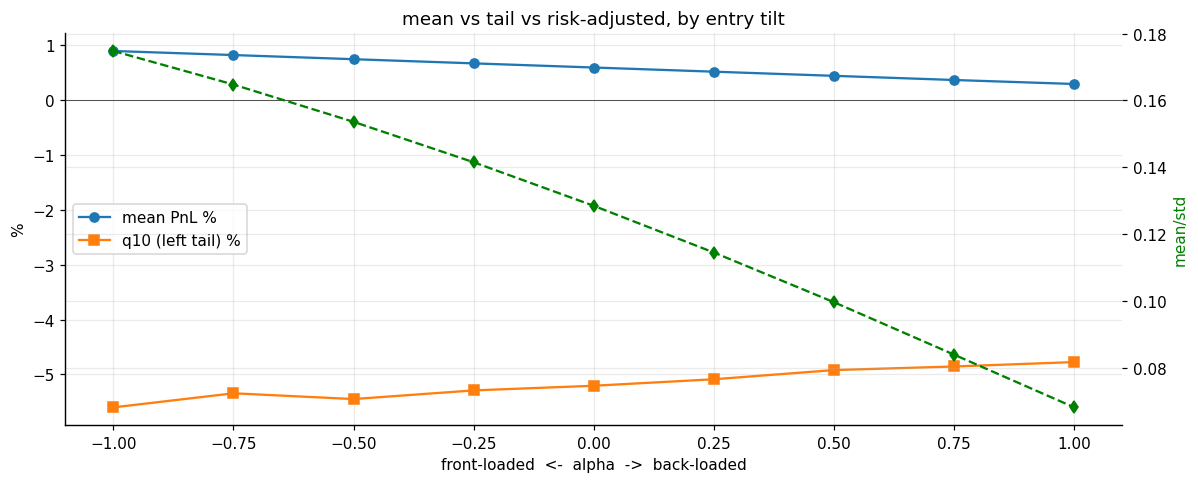

In [4]:
# linear weight ramps across 4 tranches at 0/15/30/45; alpha tilts front->back
tranches = [0, 15, 30, 45]
alphas = np.linspace(-1, 1, 9)   # -1 = front-loaded, 0 = uniform, +1 = back-loaded
means, q10s, sharpes = [], [], []
for al in alphas:
    w = np.array([1 + al*(k - 1.5)/1.5 for k in range(4)])  # tilt around uniform
    w = np.clip(w, 0.01, None)
    prof = list(zip(tranches, w))
    p = short_pnl(prof)
    means.append(p.mean()*100); q10s.append(np.quantile(p, .1)*100); sharpes.append(p.mean()/p.std())

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(alphas, means, 'o-', label='mean PnL %')
ax.plot(alphas, q10s, 's-', label='q10 (left tail) %')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('front-loaded  <-  alpha  ->  back-loaded'); ax.set_ylabel('%')
ax2 = ax.twinx(); ax2.plot(alphas, sharpes, 'd--', color='green', label='mean/std')
ax2.set_ylabel('mean/std', color='green')
ax.legend(loc='center left'); ax.set_title('mean vs tail vs risk-adjusted, by entry tilt')
show('05_scale_sweep')
best = int(np.argmax(sharpes))
print(f'best mean/std at alpha={alphas[best]:+.2f}: mean {means[best]:+.2f}%, q10 {q10s[best]:+.2f}%, m/std {sharpes[best]:.3f}')